# RaCo Figure 13 形式の可視化：XFeat + RaCo 蒸留モデル（step 3800）

**対象は [raco-local-kd-v1](https://github.com/yuki-inaho/accelerated_features/releases/tag/raco-local-kd-v1) の Q 最大・step 3800 モデルです。公式 RaCo の予測ではありません。**

[原論文 Appendix D](https://arxiv.org/html/2602.15755v1#A4) と Figure 13 の構成を参考に、**Keypoints / Detector Scoremap / Ranker Scoremap / Covariance Ellipse Major Axis Angle** の4列を表示します。表示方法を合わせた比較であり、公式モデルの描画設定を厳密に再現したものではありません。

重みのSHA-256を固定し、10組のTUM RGB-D画像のRGB計20枚から図を再生成します。候補・rank・共分散の数値は描画前後で照合し、表示用の密な拡張と実際の疎な予測を区別します。


## 再実行条件

リポジトリのルート、または `notebooks/` から全セル実行します。入力画像と重みはNotebookへ埋め込まず、計算した図だけを保存します。画像は `data/tum_rgbd_pairs_10/` または `~/Downloads/tum_rgbd_pairs_10/`、重みは `weights/xfeat-raco-local-kd-step3800-best.pt` または `~/Downloads/` の同名ファイルを探します。環境変数 `RACO_DATA_DIR` / `RACO_WEIGHTS` でも指定できます。

重みは[公開リリース](https://github.com/yuki-inaho/accelerated_features/releases/tag/raco-local-kd-v1)から取得します。期待するSHA-256は `7576862b55382f61e31fa14d68e1ef2e2be5db93a570ad7978de46427a6cf717` です。入力は640×480、リサイズなし。CPU・FP32・seed=20260927・4スレッドで実行します。manifest記載のRGBとDepthのSHA-256を確認しますが、Depthはこの可視化に使いません。

```bash
# Notebook用の依存が環境にない場合
uv run --with nbclient --with nbformat --with ipykernel --no-sync python -m scripts.execute_paper_notebook
```

生成物はgitignore対象の `outputs/raco-paper-visualization/` に保存します。TUM RGB-D画像の出典は [Sturm et al., IROS 2012](https://cvg.cit.tum.de/data/datasets/rgbd-dataset)、ライセンスは [CC BY 4.0](https://creativecommons.org/licenses/by/4.0/) です。


In [1]:
from pathlib import Path
import io
import json
import sys
import platform

import numpy as np
import torch
import matplotlib
from PIL import Image as PILImage
from IPython.display import Image, display

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
assert (ROOT / "scripts/raco_paper_visualization.py").is_file(), "Open from the repository root or notebooks/"
sys.path.insert(0, str(ROOT))

from scripts.raco_paper_visualization import DisplayConfig, run, resolve_visualization_paths
from scripts.raco_visualization_evidence import build_evidence
from scripts.raco_visualization import file_sha

MODEL_NAME = "xfeat-raco-local-kd-step3800-best.pt"
MODEL_SHA256 = "7576862b55382f61e31fa14d68e1ef2e2be5db93a570ad7978de46427a6cf717"
DEVICE = "cpu"
CONFIG = DisplayConfig(top_k=512, det_scale_px4=1.0)
DATA, WEIGHTS, OUTPUT = resolve_visualization_paths(ROOT, model_name=MODEL_NAME)
assert file_sha(WEIGHTS) == MODEL_SHA256, "The selected step-3800 release weight is required"

def show(path, width=1440):
    # Notebook previews only. Full-resolution evidence remains in the PNG files.
    with PILImage.open(path) as image:
        image = image.convert("RGB")
        if image.width > width:
            image.thumbnail((width, 100000), PILImage.Resampling.LANCZOS)
        stream = io.BytesIO()
        image.save(stream, format="PNG")
    display(Image(data=stream.getvalue()))

print(json.dumps({"python": platform.python_version(), "torch": torch.__version__,
                  "numpy": np.__version__, "matplotlib": matplotlib.__version__,
                  "device": DEVICE, "model_file": WEIGHTS.name,
                  "model_sha256": file_sha(WEIGHTS)}, indent=2))


{
  "python": "3.12.12",
  "torch": "2.14.0+cu130",
  "numpy": "2.5.3",
  "matplotlib": "3.11.2",
  "device": "cpu",
  "model_file": "xfeat-raco-local-kd-step3800-best.pt",
  "model_sha256": "7576862b55382f61e31fa14d68e1ef2e2be5db93a570ad7978de46427a6cf717"
}


## 表示している量

| 項目 | step 3800 モデルの主図 |
|---|---|
| Keypoints | 候補から実際の最終rankで選んだ上位512点 |
| Detector | XFeatのセル内softmax確率 $p$ を固定 [0,1] で表示 |
| Ranker | 実際の選択式を候補外へ延長したscoreを固定 [-3,3] で表示 |
| Covariance | 密な共分散の長軸角を色、行列式を白さで表示 |

この $p$ は公式RaCoの画像全体softmaxとは正規化単位が異なります。選択には信頼度を掛けた $s=pq$ を使います。

最終rankは `tanh((log(s+1e-8)-mu)/std) + 2*tanh(delta)`。`mu` と `std=sqrt(var+1e-6)` は **top-k前の全候補集合** で算出します。候補位置は疎なAPIとの一致を確認します。候補外は表示用の式の拡張であり、密な順位予測の精度を主張しません。


scene_01_a: N=3163, top=512, rank err=5.96e-07, min eig=0.2575


scene_01_b: N=3664, top=512, rank err=4.77e-07, min eig=0.1697


scene_02_a: N=3697, top=512, rank err=4.77e-07, min eig=0.2415


scene_02_b: N=3499, top=512, rank err=5.36e-07, min eig=0.2302


scene_03_a: N=3385, top=512, rank err=7.15e-07, min eig=0.2502


...

scene_08_b: N=4601, top=512, rank err=4.77e-07, min eig=0.1710


scene_09_a: N=4579, top=512, rank err=4.77e-07, min eig=0.1694


scene_09_b: N=4559, top=512, rank err=4.77e-07, min eig=0.1331


scene_10_a: N=4543, top=512, rank err=4.77e-07, min eig=0.1181


scene_10_b: N=4618, top=512, rank err=4.77e-07, min eig=0.1519


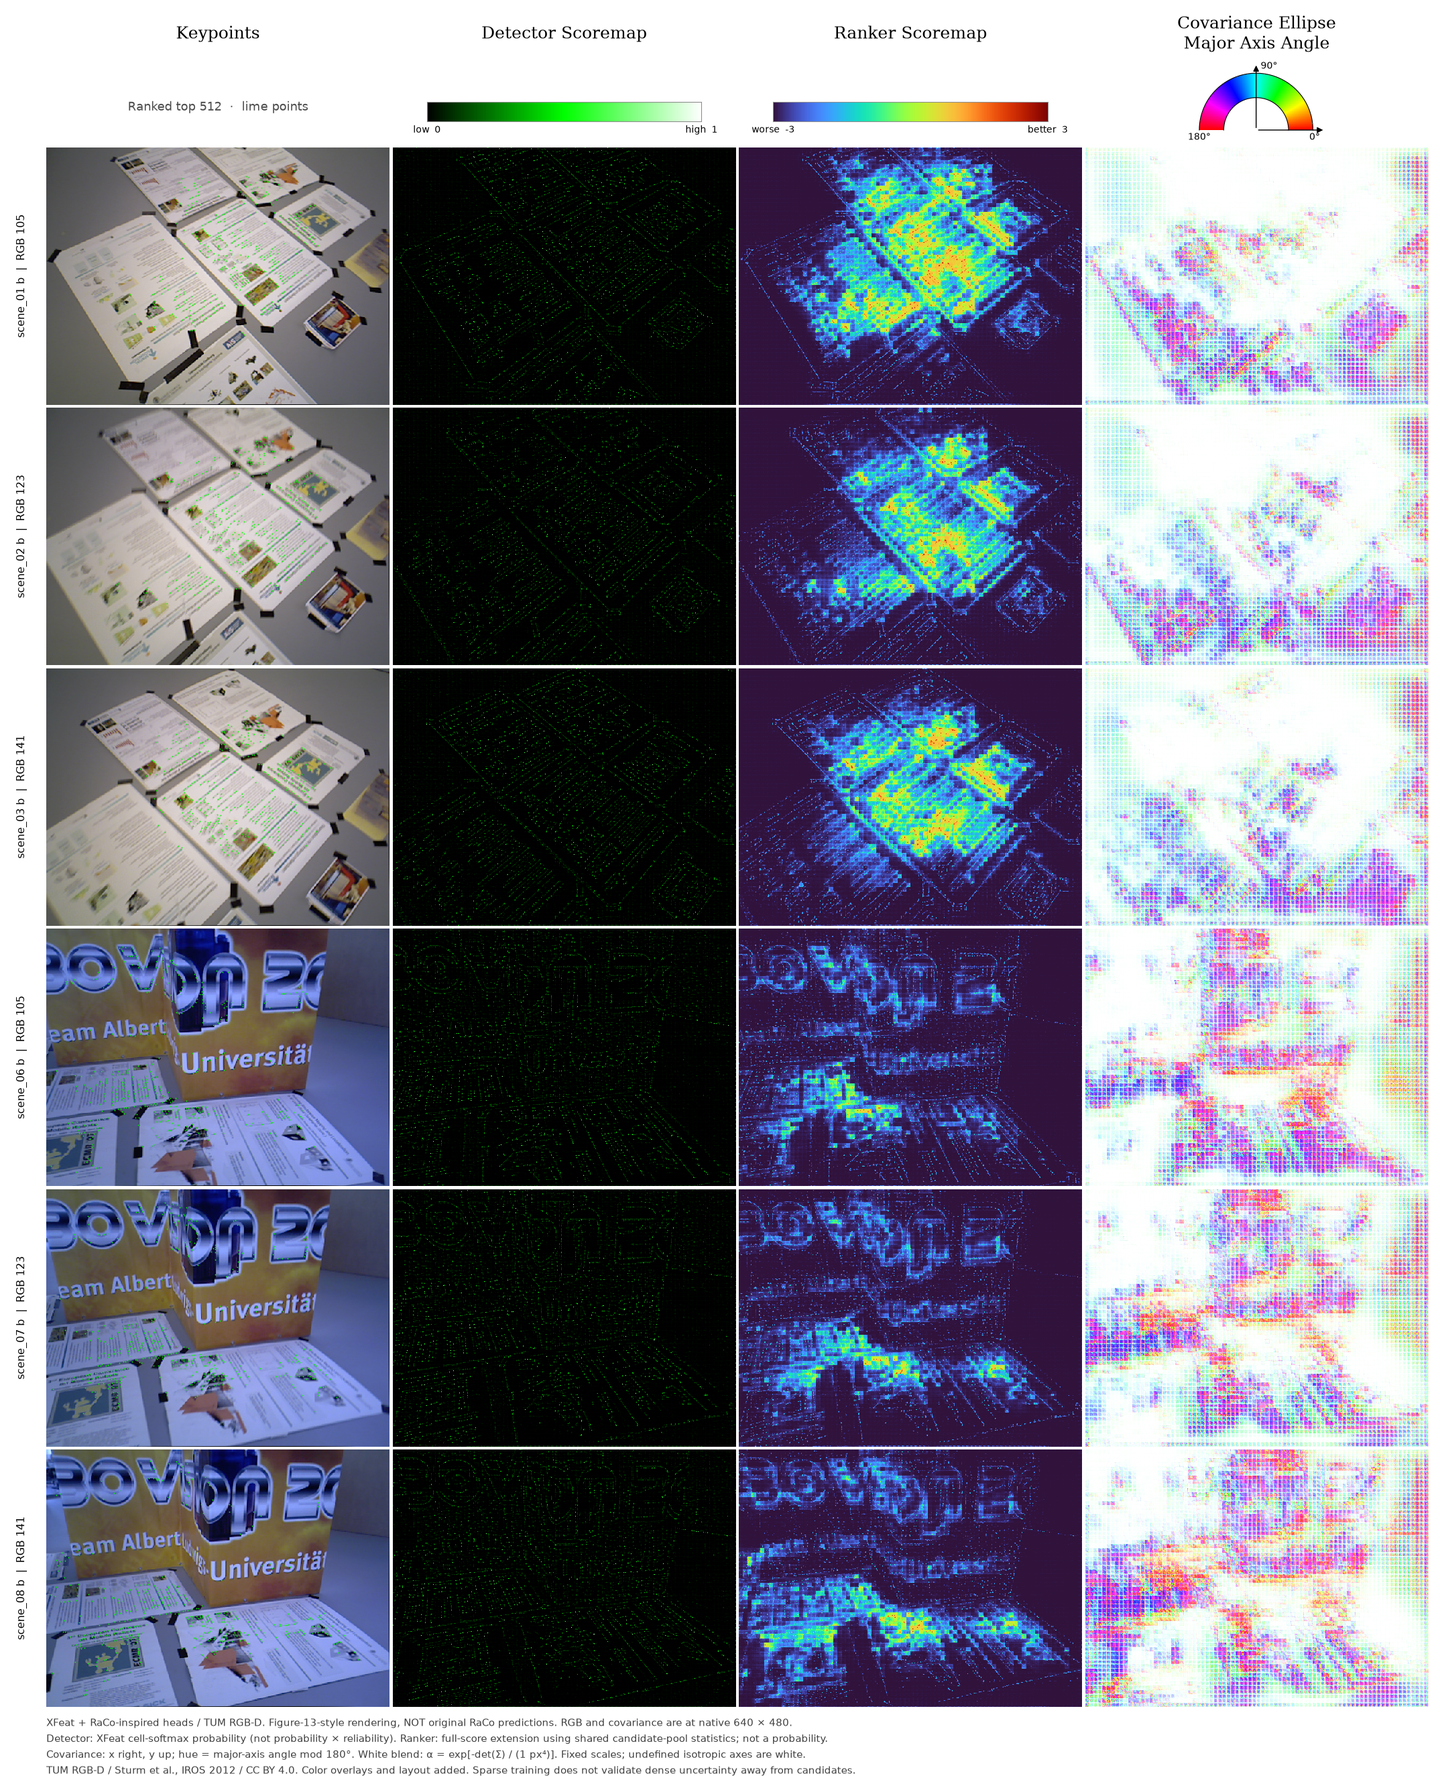

Candidate total: 80490
Original-size figure: raco-paper-visualization/paper_style_gallery.png
Native maps: raco-paper-visualization/native/<scene_view>/ (640x480)


In [2]:
result = run(DATA, WEIGHTS, OUTPUT, device=DEVICE, config=CONFIG,
             expected_model_sha256=MODEL_SHA256)
verification = result["verification"]
assert verification["views"] == 20
assert verification["model_sha256"] == MODEL_SHA256
assert all(row["candidates"] >= row["selected"] > 0 for row in verification["frames"])
show(OUTPUT / "paper_style_gallery.png")
print("Candidate total:", sum(row["candidates"] for row in verification["frames"]))
print("Original-size figure:", OUTPUT.name + "/paper_style_gallery.png")
print("Native maps:", OUTPUT.name + "/native/<scene_view>/ (640x480)")


## 共分散：色と白さの意味

$\Sigma=LL^\top+0.05^2I$ [px²] を固有分解し、最大固有値の固有ベクトルを $v_{\max}$ とします。画像のyは下向き、凡例は上向きなので `theta = atan2(-v_y, v_x) mod pi`。長軸は向きのない直線で、色は180度周期です。

`HSV(theta/pi, 1, 1)` を色相とし、`alpha = exp(-det(Sigma)/tau)`、`RGB = alpha*hue + (1-alpha)*white` とします。`tau=1 px^4` を全画像で固定しました。論文には行列式による白化の記述がありますが、この関数と尺度は本Notebookの表示設定です。

相対固有値差が1e-6以下の場所は長軸角を未定義として白くします。非有限・非対称・非正定値の行列はエラーにします。白さは特徴点の有無や校正済みの確率を表しません。


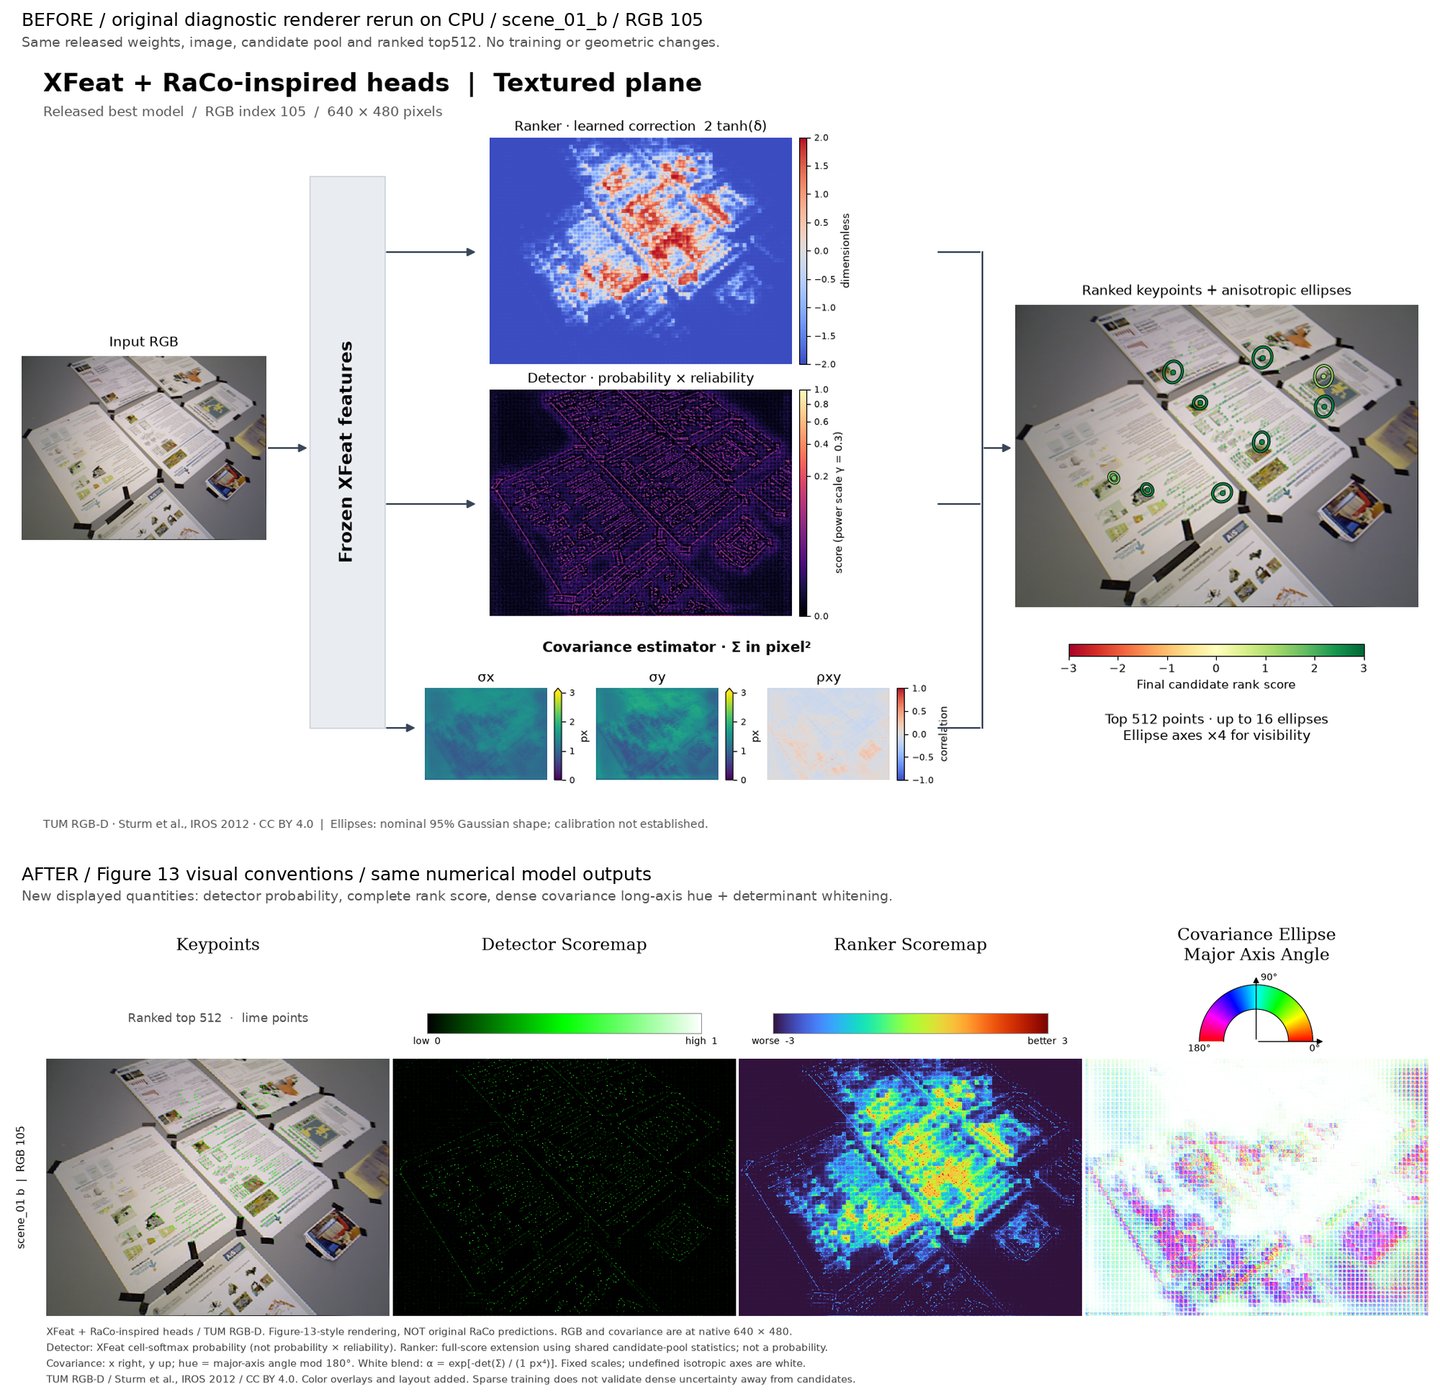

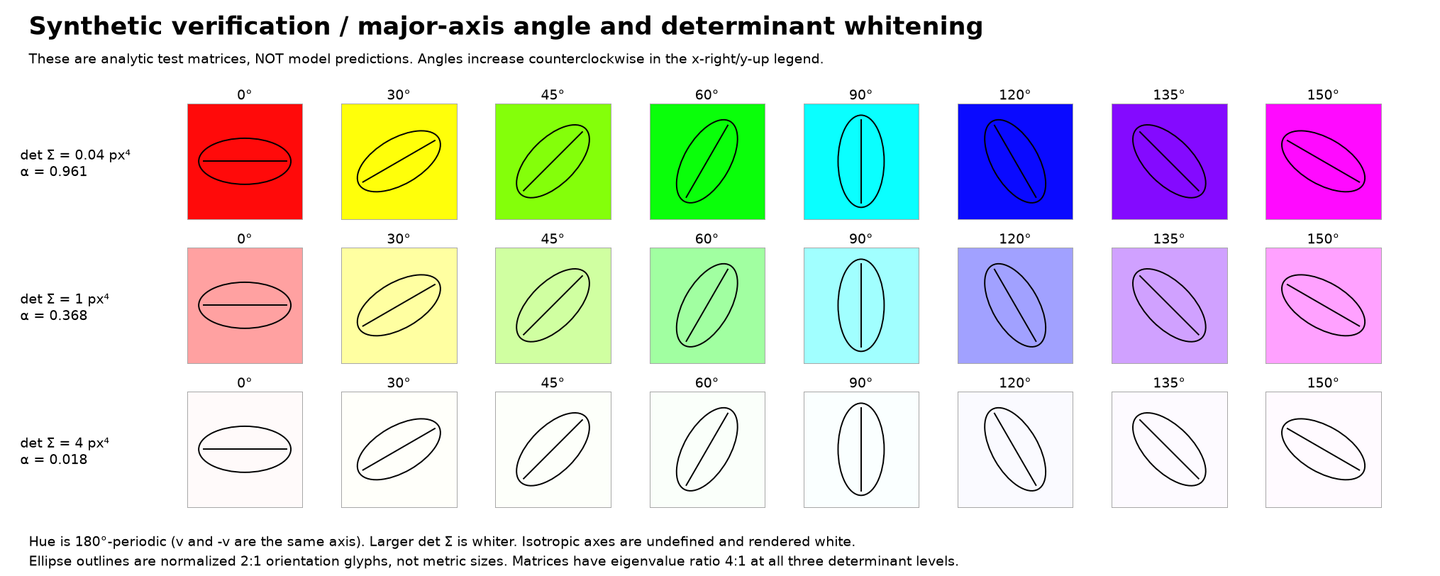

Before/after for the other sequence: raco-paper-visualization/before_after_scene_06_b.png


In [3]:
extra_paths = build_evidence(ROOT, OUTPUT, verify=True, weights=WEIGHTS)
show(OUTPUT / "before_after_scene_01_b.png")
show(OUTPUT / "orientation_whitening_proof.png")
print("Before/after for the other sequence:", OUTPUT.name + "/before_after_scene_06_b.png")


## 補正項と最終rankの違い

次の左・中央は同じ補正項で、色だけが違います。右は検出スコアの事前項を含む最終rankの密な表示用拡張です。学習済みのstep 3800重みを使い、同じ画像からそれぞれ計算しています。


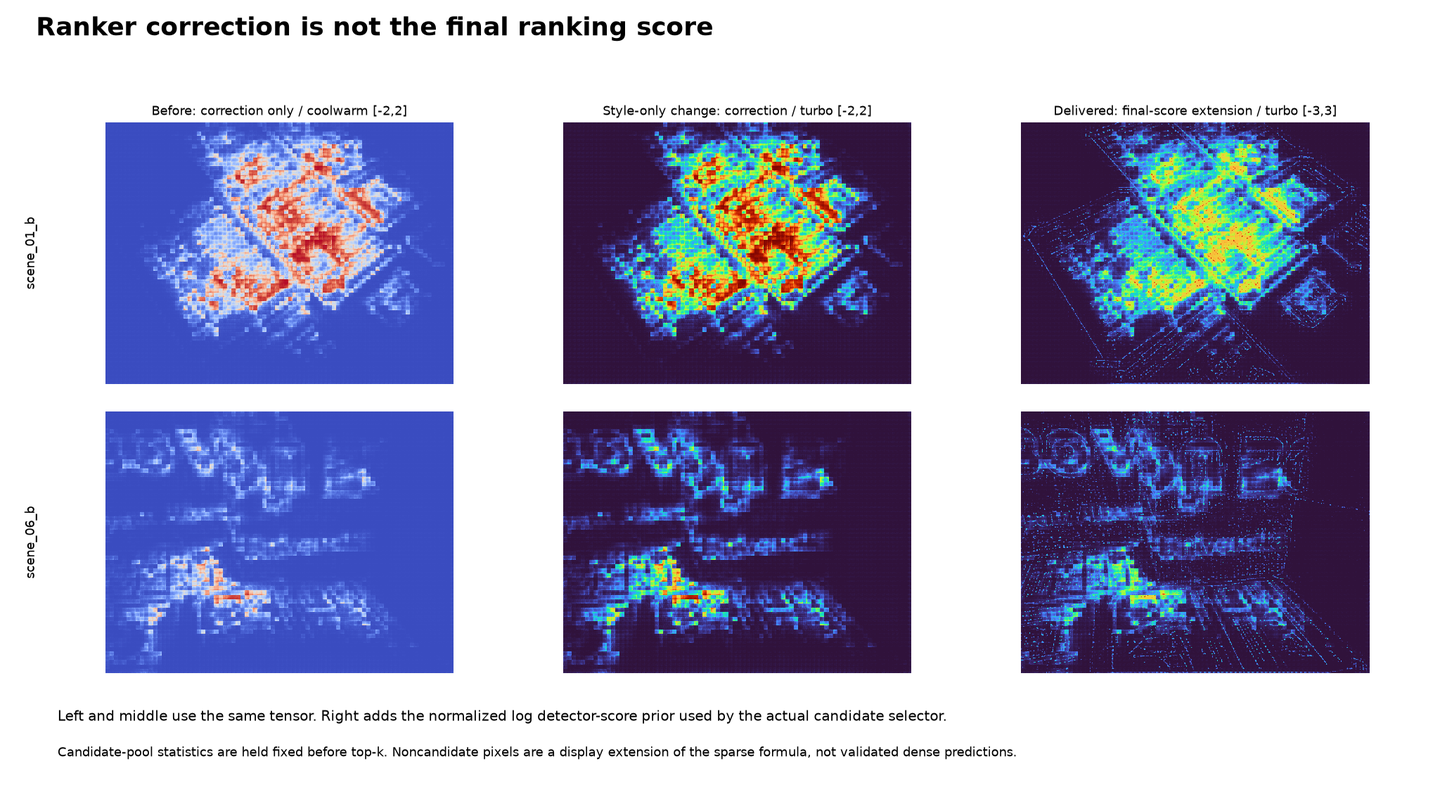

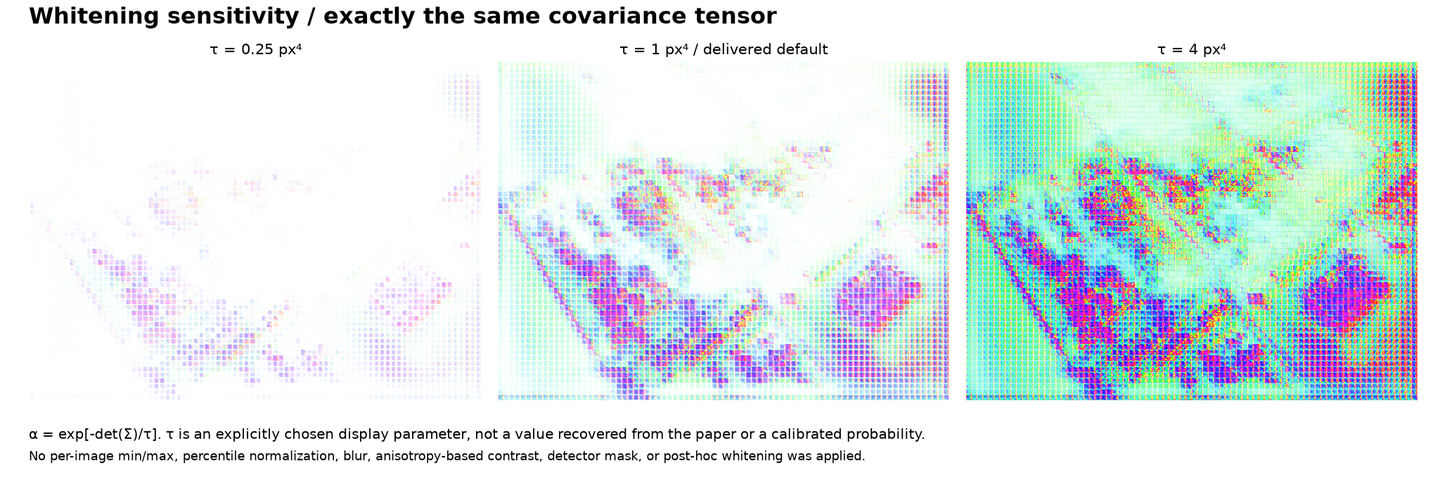

In [4]:
show(OUTPUT / "rank_semantics.png")
show(OUTPUT / "whitening_sensitivity.png")

## この図から読めることと範囲

図はstep 3800モデルの検出点、検出確率、順位スコア、共分散場を、10組のTUM RGB-D画像上で可視化します。公式RaCoとは検出確率の正規化、候補生成、順位スコアの値域が異なります。色の似方から蒸留精度を判定しません。

以下の診断値は本Notebookを実行した重みと20画像から算出します。格子模様があっても、原因をこの図だけで断定しません。共分散の校正、実測被覆率、追跡・姿勢性能はこの可視化の対象外です。これらの評価は [蒸留結果Notebook](raco_distillation.ipynb) を参照してください。

埋め込んだ画像は閲覧用に縮小したものです。全解像度PNG、数値配列NPZ、検証JSONはローカルの `outputs/raco-paper-visualization/` に生成されます。
